In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [26]:
train

,ID,report,target
0,Acc1,Indicação clínica:\n\r rastreamento.\n\rAchado...,2
1,Acc3,Indicação clínica:\n\r rastreamento.\n\rAchado...,2
2,Acc5,Indicação clínica:\n\r rastreamento.\n\rAchado...,2
3,Acc6,Indicação clínica:\n\r reavaliação de alteraçã...,2
4,Acc7,Indicação clínica:\n\r reavaliação de alteraçã...,2
...,...,...,...
18267,Acc22766,Indicação clínica:\n\rrastreamento .\n\rDescri...,2
18268,Acc22767,Indicação clínica:\n\rrastreamento.\n\rAchados...,2
18269,Acc22768,Indicação clínica:\n\rrastreamento.\n\rAchados...,2
18270,Acc22770,Indicação clínica:\n\rrastreamento.\n\rAchados...,2


In [27]:
train.isna().sum()

ID        0
report    0
target    0
dtype: int64

In [28]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18272 entries, 0 to 18271
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      18272 non-null  object
 1   report  18272 non-null  object
 2   target  18272 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 428.4+ KB


,target
count,18272.000000
mean,1.972362
std,0.557024
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,6.000000


In [29]:
train.report.sample()

17578    Indicação clínica:\n\rrastreamento.\n\rAchados...
Name: report, dtype: object

In [30]:
train.target.value_counts() * 100 / len(train)

target
2    87.390543
3     3.902145
1     3.792688
0     3.338441
4     1.171191
6     0.246278
5     0.158713
Name: count, dtype: float64

In [31]:
train.report.map(lambda x: "rastreamento" in x).value_counts() * 100 / len(train)

report
True     93.71169
False     6.28831
Name: count, dtype: float64

In [32]:
train.report.map(
    lambda x: "reavaliação de alteração observada à mamografia de <DATA>" in x
).value_counts() * 100 / len(train)

report
False    98.905429
True      1.094571
Name: count, dtype: float64

In [33]:
train.groupby("target").report.apply(
    lambda x: x.map(lambda y: "rastreamento" in y).value_counts() * 100 / len(x)
)

target       
0       True     86.721311
        False    13.278689
1       True     96.248196
        False     3.751804
2       True     94.921092
        False     5.078908
3       True     82.187938
        False    17.812062
4       True     74.299065
        False    25.700935
5       False    72.413793
        True     27.586207
6       False    62.222222
        True     37.777778
Name: report, dtype: float64

In [34]:
train.groupby("target").report.apply(
    lambda x: x.map(
        lambda y: "reavaliação de alteração observada à mamografia de <DATA>" in y
    ).value_counts()
    * 100
    / len(x)
)

target       
0       False     96.393443
        True       3.606557
1       False     98.268398
        True       1.731602
2       False     99.223447
        True       0.776553
3       False     95.371669
        True       4.628331
4       False     97.196262
        True       2.803738
5       False    100.000000
6       False     93.333333
        True       6.666667
Name: report, dtype: float64

<Axes: xlabel='target', ylabel='Count'>

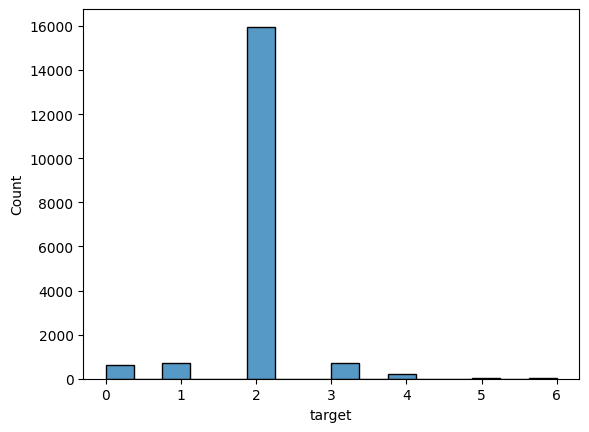

In [35]:
sns.histplot(train.target)

## Feature Extraction from Report Sections

In [36]:
import re


def extract_indicacao(text):
    """Extract text between 'Indicação clínica:' and the next section."""
    m = re.search(
        r"Indicação clínica:\s*[\n\r]+\s*(.*?)(?=[\n\r]+(?:Achados|Realizad|Mamas|Tecido|Calc|Impl|Alt|Desc))",
        text,
        re.DOTALL,
    )
    if m:
        return m.group(1).strip()
    return None


def classify_indicacao(text):
    """Map raw indicação text to a high-level category."""
    if pd.isna(text):
        return "desconhecido"
    t = text.lower().replace("\n", " ").replace("\r", " ").strip().rstrip(".")
    if "reavaliação" in t or "reavaliaçao" in t:
        return "reavaliacao"
    if "rastreamento" in t and "controle" in t:
        return "rastreamento_controle"
    if "rastreamento" in t:
        return "rastreamento"
    if "controle" in t:
        return "controle"
    if "primeiro exame" in t or "primeira mamografia" in t:
        return "primeiro_exame"
    if "rotina" in t:
        return "rotina"
    if "sintomática" in t or "nódulo palpável" in t or "queixa" in t:
        return "sintomatica"
    return "outro"


def extract_achados(text):
    """Extract the Achados section from the report."""
    m = re.search(
        r"Achados:\s*[\n\r]+(.*?)(?=[\n\r]+Análise comparativa:|$)", text, re.DOTALL
    )
    if m:
        return m.group(1).strip()
    m = re.search(
        r"Indicação clínica:.*?[\n\r]+.*?\.[\n\r]+(.*?)(?=[\n\r]+Análise comparativa:|$)",
        text,
        re.DOTALL,
    )
    if m:
        return m.group(1).strip()
    return None


def extract_analise_comparativa(text):
    """Extract the Análise comparativa section from the report."""
    m = re.search(r"Análise comparativa:\s*[\n\r]+(.*?)$", text, re.DOTALL)
    if m:
        return m.group(1).strip()
    return None

In [37]:
train["indicacao_raw"] = train["report"].apply(extract_indicacao)
train["indicacao_class"] = train["indicacao_raw"].apply(classify_indicacao)
train["achados"] = train["report"].apply(extract_achados)
train["analise_comparativa"] = train["report"].apply(extract_analise_comparativa)

print(f"indicacao_class nulls: {(train['indicacao_class'] == 'desconhecido').sum()}")
print(f"achados nulls: {train['achados'].isna().sum()}")
print(f"analise_comparativa nulls: {train['analise_comparativa'].isna().sum()}")

train[["ID", "indicacao_class", "achados", "analise_comparativa", "target"]].head(10)

indicacao_class nulls: 20
achados nulls: 5
analise_comparativa nulls: 341


,ID,indicacao_class,achados,analise_comparativa,target
0,Acc1,rastreamento,Mamas parcialmente lipossubstituídas.\n\rCalci...,Imagens de mamografias anteriores não disponív...,2
1,Acc3,rastreamento,Mamas parcialmente lipossubstituídas.\n\rCalci...,Mamografias anteriores não disponíveis para an...,2
2,Acc5,rastreamento,Mamas parcialmente lipossubstituídas.\n\rCalci...,"Em relação ao exame de <DATA>, não se observam...",2
3,Acc6,reavaliacao,Calcificações benignas esparsas.\n\rAssimetria...,None,2
4,Acc7,reavaliacao,Calcificações benignas esparsas.\n\rAssimetria...,None,2
5,Acc8,rastreamento,Mamas parcialmente lipossubstituídas.\n\rAssim...,"Em relação ao exame de <DATA>, não se observam...",3
6,Acc9,reavaliacao,"Nódulo isodenso, de margens circunscritas, med...",None,3
7,Acc12,reavaliacao,Calcificações benignas esparsas.\n\rAssimetria...,None,2
8,Acc14,reavaliacao,"Mama densa, pelo predomínio de tecido fibrogla...",None,2
9,Acc15,reavaliacao,Calcificações benignas esparsas.\n\rAssimetria...,None,0


### Indicação Clínica class distribution

In [38]:
print("=== Indicação clínica class distribution ===")
print(train["indicacao_class"].value_counts())

print("\n=== Cross-tab: indicação class × target ===")
pd.crosstab(train["indicacao_class"], train["target"], normalize="index").round(3)

=== Indicação clínica class distribution ===
indicacao_class
rastreamento             17467
reavaliacao                224
rastreamento_controle      188
outro                      145
controle                   123
rotina                      53
sintomatica                 40
desconhecido                20
primeiro_exame              12
Name: count, dtype: int64

=== Cross-tab: indicação class × target ===


target,0,1,2,3,4,5,6
indicacao_class,,,,,,,
controle,0.041,0.000,0.455,0.455,0.033,0.000,0.016
desconhecido,0.150,0.000,0.600,0.100,0.050,0.000,0.100
outro,0.034,0.041,0.614,0.090,0.083,0.069,0.069
primeiro_exame,0.000,0.000,1.000,0.000,0.000,0.000,0.000
rastreamento,0.032,0.039,0.888,0.031,0.009,0.000,0.001
rastreamento_controle,0.016,0.000,0.638,0.330,0.016,0.000,0.000
reavaliacao,0.107,0.058,0.643,0.147,0.027,0.000,0.018
rotina,0.075,0.000,0.283,0.038,0.340,0.170,0.094
sintomatica,0.075,0.000,0.375,0.025,0.350,0.050,0.125


### OHE columns for Achados findings

In [39]:
achados_patterns = {
    "achado_calcif_benignas": r"[Cc]alcificações benignas",
    "achado_sem_calcif_suspeitas": r"[Nn]ão se observam (?:calcificações suspeitas|microcalcificações pleomórficas|calcificações pleomórficas)",
    "achado_axilares_normais": r"regiões? axilares? não apresenta",
    "achado_mamas_lipossubst": r"[Mm]amas? parcialmente lipossubstituídas",
    "achado_mamas_densas_fibro": r"[Mm]amas? com densidades fibroglandulares",
    "achado_mamas_hetero_densas": r"[Mm]amas? heterogeneamente densas",
    "achado_mamas_densas_predom": r"[Mm]amas? densas? pelo predomínio",
    "achado_mamas_extrem_densas": r"[Mm]amas? extremamente densas",
    "achado_mamas_predom_adiposas": r"[Mm]amas? predominantemente (?:adiposas|lipossubstituídas)",
    "achado_linfonodo_intramamario": r"[Ll]infonodo[s]? intramamário",
    "achado_assimetria": r"[Aa]ssimetria",
    "achado_nodulo": r"[Nn]ódulo",
    "achado_distorcao_arquitetural": r"[Dd]istorção arquitetural",
    "achado_alteracao_cirurgica": r"manipulação cirúrgica|procedimento cirúrgico",
    "achado_implante_mamario": r"[Ii]mplantes? mamários?",
    "achado_manobra_eklund": r"manobra de Eklund",
    "achado_marcador_radiopaco": r"[Mm]arcador radiopaco",
    "achado_linfonodos_axilares": r"[Ll]infonodos? axilares?",
    "achado_calcif_vasculares": r"calcificações.*vasculares|vasculares",
    "achado_microcalcificacoes": r"[Mm]icrocalcificaç",
    "achado_espessamento_cutaneo": r"[Ee]spessamento cutâneo",
    "achado_retracao": r"[Rr]etração",
}

for col_name, pattern in achados_patterns.items():
    train[col_name] = train["achados"].str.contains(pattern, na=False).astype(int)

achado_cols = list(achados_patterns.keys())

target_dummies = pd.get_dummies(train["target"], prefix="target")
mean_abs_corr = pd.Series(
    {col: target_dummies.corrwith(train[col]).abs().mean() for col in achado_cols}
)

CORR_THRESHOLD = 0.02
low_corr_cols = mean_abs_corr[mean_abs_corr <= CORR_THRESHOLD].index.tolist()
print(f"Dropping {len(low_corr_cols)} features with mean abs corr <= {CORR_THRESHOLD}:")
for c in low_corr_cols:
    print(f"  {c}: {mean_abs_corr[c]:.4f}")

train.drop(columns=low_corr_cols, inplace=True)
achado_cols = [c for c in achado_cols if c not in low_corr_cols]

print(f"\nKept {len(achado_cols)} OHE columns for Achados")
train[["ID", "target"] + achado_cols].head(10)

Created 22 OHE columns for Achados


,ID,target,achado_calcif_benignas,achado_sem_calcif_suspeitas,achado_axilares_normais,achado_mamas_lipossubst,achado_mamas_densas_fibro,achado_mamas_hetero_densas,achado_mamas_densas_predom,achado_mamas_extrem_densas,...,achado_distorcao_arquitetural,achado_alteracao_cirurgica,achado_implante_mamario,achado_manobra_eklund,achado_marcador_radiopaco,achado_linfonodos_axilares,achado_calcif_vasculares,achado_microcalcificacoes,achado_espessamento_cutaneo,achado_retracao
0,Acc1,2,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Acc3,2,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Acc5,2,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Acc6,2,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Acc7,2,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,Acc8,3,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Acc9,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,Acc12,2,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
8,Acc14,2,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
9,Acc15,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
print("=== Achado column frequencies ===")
for col in achado_cols:
    n = train[col].sum()
    pct = n / len(train) * 100
    print(f"  {col}: {n:>6} ({pct:5.1f}%)")

=== Achado column frequencies ===
  achado_calcif_benignas:  17209 ( 94.2%)
  achado_sem_calcif_suspeitas:  17467 ( 95.6%)
  achado_axilares_normais:  17367 ( 95.0%)
  achado_mamas_lipossubst:   3942 ( 21.6%)
  achado_mamas_densas_fibro:   6332 ( 34.7%)
  achado_mamas_hetero_densas:   4436 ( 24.3%)
  achado_mamas_densas_predom:   1778 (  9.7%)
  achado_mamas_extrem_densas:    434 (  2.4%)
  achado_mamas_predom_adiposas:    737 (  4.0%)
  achado_linfonodo_intramamario:   2185 ( 12.0%)
  achado_assimetria:   1096 (  6.0%)
  achado_nodulo:   6071 ( 33.2%)
  achado_distorcao_arquitetural:    295 (  1.6%)
  achado_alteracao_cirurgica:    839 (  4.6%)
  achado_implante_mamario:    287 (  1.6%)
  achado_manobra_eklund:    278 (  1.5%)
  achado_marcador_radiopaco:    304 (  1.7%)
  achado_linfonodos_axilares:    451 (  2.5%)
  achado_calcif_vasculares:   1485 (  8.1%)
  achado_microcalcificacoes:   1522 (  8.3%)
  achado_espessamento_cutaneo:     60 (  0.3%)
  achado_retracao:     27 (  0.1%)


### Achados OHE correlation with target

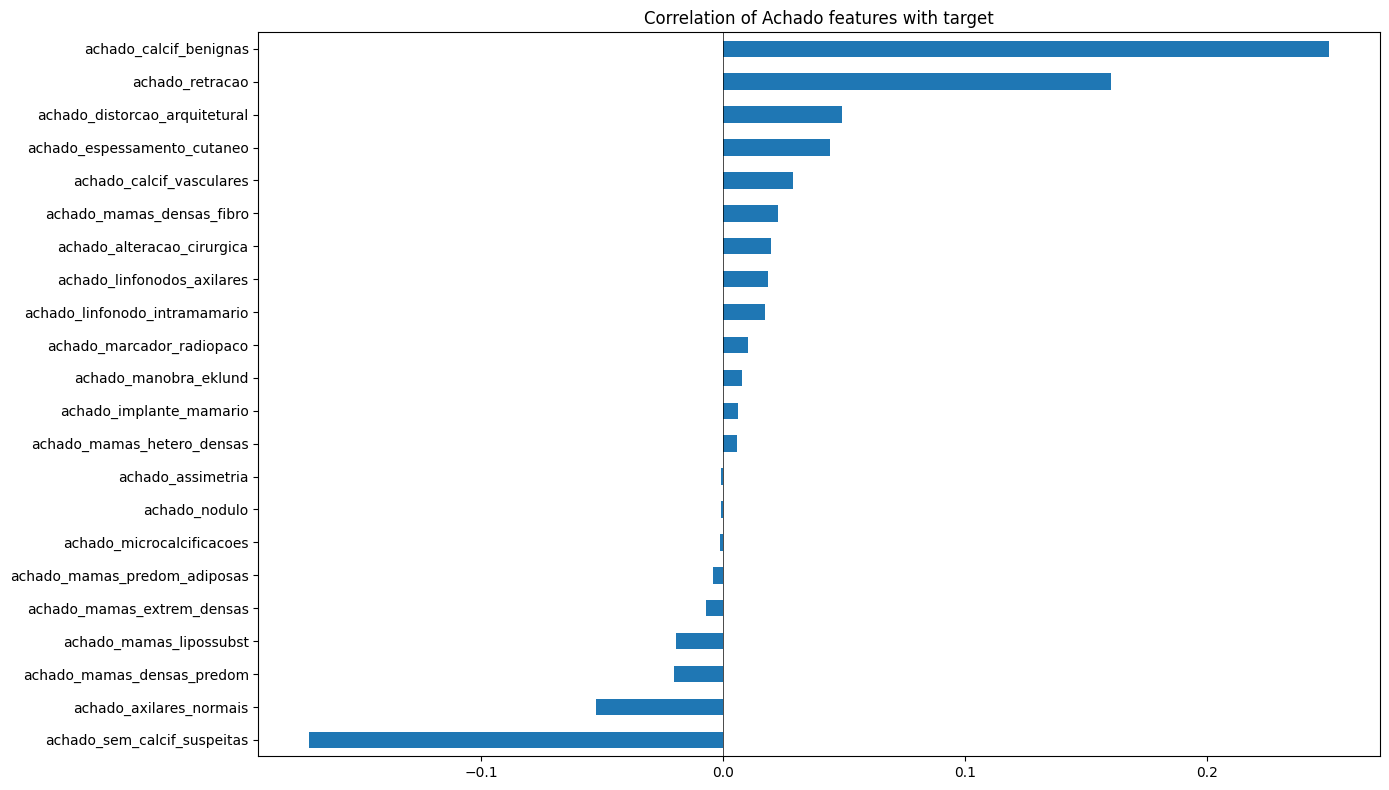

In [41]:
fig, ax = plt.subplots(figsize=(14, 8))
corr = train[achado_cols + ["target"]].corr()["target"].drop("target").sort_values()
corr.plot.barh(ax=ax)
ax.set_title("Correlation of Achado features with target")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Achado OHE mean by target class

In [42]:
achados_by_target = train.groupby("target")[achado_cols].mean().T
achados_by_target.style.background_gradient(cmap="YlOrRd", axis=1).format("{:.3f}")

target,0,1,2,3,4,5,6
achado_calcif_benignas,0.939,0.006,0.984,0.928,0.893,0.862,0.844
achado_sem_calcif_suspeitas,0.856,0.974,0.976,0.790,0.411,0.552,0.511
achado_axilares_normais,0.928,0.949,0.956,0.909,0.874,0.690,0.622
achado_mamas_lipossubst,0.311,0.113,0.218,0.209,0.121,0.069,0.333
achado_mamas_densas_fibro,0.216,0.407,0.350,0.318,0.346,0.655,0.267
achado_mamas_hetero_densas,0.211,0.315,0.239,0.259,0.364,0.207,0.111
achado_mamas_densas_predom,0.190,0.029,0.096,0.116,0.093,0.034,0.089
achado_mamas_extrem_densas,0.011,0.046,0.024,0.015,0.019,0.000,0.022
achado_mamas_predom_adiposas,0.010,0.061,0.042,0.021,0.014,0.000,0.022
achado_linfonodo_intramamario,0.100,0.001,0.127,0.095,0.084,0.034,0.067


### Análise comparativa distribution

In [43]:
print(
    f"Has análise comparativa: {train['analise_comparativa'].notna().sum()} ({train['analise_comparativa'].notna().mean()*100:.1f}%)"
)
print(f"Missing: {train['analise_comparativa'].isna().sum()}")
print(f"\n=== Top 15 values ===")
print(train["analise_comparativa"].value_counts().head(15))

Has análise comparativa: 17931 (98.1%)
Missing: 341

=== Top 15 values ===
analise_comparativa
Mamografias anteriores não disponíveis para análise comparativa.                                                                                 8077
Em relação ao exame de <DATA>, não se observam alterações significativas.                                                                        5893
Primeira mamografia.                                                                                                                              229
Primeiro exame.                                                                                                                                   214
Em relação ao exame de <DATA> (apenas laudo), não se observam alterações significativas.                                                          203
Em relação ao exame de <DATA> não se observam alterações significativas.                                                                          200
Prime

### Summary of extracted features

In [44]:
new_cols = ["indicacao_class", "analise_comparativa"] + achado_cols
print(f"Total new columns: {len(new_cols)}")
print(f"Shape: {train.shape}")
train[["ID", "target", "indicacao_class", "analise_comparativa"] + achado_cols].sample(
    5, random_state=42
)

Total new columns: 24
Shape: (18272, 29)


,ID,target,indicacao_class,analise_comparativa,achado_calcif_benignas,achado_sem_calcif_suspeitas,achado_axilares_normais,achado_mamas_lipossubst,achado_mamas_densas_fibro,achado_mamas_hetero_densas,...,achado_distorcao_arquitetural,achado_alteracao_cirurgica,achado_implante_mamario,achado_manobra_eklund,achado_marcador_radiopaco,achado_linfonodos_axilares,achado_calcif_vasculares,achado_microcalcificacoes,achado_espessamento_cutaneo,achado_retracao
14509,Acc18010,2,rastreamento,"Em relação ao exame de <DATA>, não se observam...",1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3887,Acc4832,0,rastreamento,Mamografias anteriores não disponíveis para an...,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
15308,Acc19014,2,rastreamento,Mamografias anteriores não disponíveis para an...,1,1,1,0,1,0,...,0,1,0,0,0,0,0,0,0,0
13525,Acc16792,2,rastreamento,Mamografias anteriores não disponíveis para an...,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
10455,Acc12950,3,rastreamento,"Em relação ao exame de <DATA>, observa-se melh...",1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["ID", "target"])
y = train["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: 'Indicação clínica:\n\r rastreamento.\n\rAchados:\n\rMarcador radiopaco na mama direita que corresponde a lesão cutânea.\n\rMamas parcialmente lipossubstituídas.\n\rCalcificações benignas esparsas.\n\rNão se observam microcalcificações pleomórficas agrupadas.\n\rAs regiões axilares não apresentam alterações significativas.\n\rMarcador metálico em nevo cutâneo em quadrante superolateral da mama direita.\n\rAnálise comparativa:\n\rMamografias anteriores não disponíveis para análise comparativa.\n\r'

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Define the pipeline

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)